# Federated Algorithm Comparison — Part 1: FedAvg & FedProx

This notebook runs **FedAvg** and **FedProx** on the MedQuAD dataset (IID split, 3 clients).
Results are saved to `fl_outputs/part1_metrics.json` so that `federated_part3_comparison.ipynb` can load and compare all four algorithms together.

| Algorithm | Key Idea | Extra Cost |
|---|---|---|
| **FedAvg** | Average client LoRA updates | Baseline |
| **FedProx** | Add proximal term `(μ/2)||w-w_global||²` to local loss | Hyperparameter μ |

**References:**
- FedAvg: McMahan et al. (2017) — *Communication-Efficient Learning of Deep Networks from Decentralized Data*
- FedProx: Li et al. (2018) — *Federated Optimization in Heterogeneous Networks*


## 1. Install dependencies

In [1]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets kagglehub trl sentencepiece scikit-learn matplotlib


In [2]:
import os, copy, random, gc, time, json
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
)
from peft import (
    LoraConfig,
    get_peft_model,
    get_peft_model_state_dict,
    set_peft_model_state_dict,
    prepare_model_for_kbit_training,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 2. Configuration

In [3]:
@dataclass
class Config:
    # --- model ---
    base_model_id: str = "google/gemma-2b"
    lora_r: int = 3
    lora_alpha: int = 8
    lora_dropout: float = 0.05
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")

    # --- quantization ---
    load_in_4bit: bool = True
    bnb_4bit_quant_type: str = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16
    bnb_4bit_use_double_quant: bool = True

    # --- data ---
    max_seq_len: int = 256
    samples_per_org: int = 300
    val_samples_per_org: int = 30
    num_clients: int = 3

    # --- local training ---
    local_epochs: int = 1
    local_batch_size: int = 2
    grad_accum_steps: int = 4
    lr: float = 2e-4
    max_steps_per_round: int = 60

    # --- federated experiment ---
    total_rounds: int = 3          # rounds to run for EACH algorithm
    fedavg_weighting: str = "uniform"  # "uniform" or "by_dataset_size"

    # --- FedProx ---
    fedprox_mu: float = 0.01       # proximal coefficient; higher = tighter to global

    # --- misc ---
    output_dir: str = "./fl_outputs"
    hf_token: Optional[str] = None

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)
CFG


Config(base_model_id='google/gemma-2b', lora_r=3, lora_alpha=8, lora_dropout=0.05, lora_target_modules=('q_proj', 'k_proj', 'v_proj', 'o_proj'), load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True, max_seq_len=256, samples_per_org=300, val_samples_per_org=30, num_clients=3, local_epochs=1, local_batch_size=2, grad_accum_steps=4, lr=0.0002, max_steps_per_round=60, total_rounds=3, fedavg_weighting='uniform', fedprox_mu=0.01, output_dir='./fl_outputs', hf_token=None)

## 3. Authentication & Model Loading

In [4]:
CFG.hf_token = "hf_xxxxxxx"

from huggingface_hub import login as hf_login
if CFG.hf_token:
    hf_login(token=CFG.hf_token)

import kagglehub
print("Auth ready.")


Auth ready.


In [5]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CFG.load_in_4bit,
    bnb_4bit_quant_type=CFG.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=CFG.bnb_4bit_compute_dtype,
    bnb_4bit_use_double_quant=CFG.bnb_4bit_use_double_quant,
)

tokenizer = AutoTokenizer.from_pretrained(CFG.base_model_id, token=CFG.hf_token)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    CFG.base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    token=CFG.hf_token,
)
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=CFG.lora_r,
    lora_alpha=CFG.lora_alpha,
    lora_dropout=CFG.lora_dropout,
    target_modules=list(CFG.lora_target_modules),
    bias="none",
    task_type="CAUSAL_LM",
)
global_model = get_peft_model(base_model, lora_config)
global_model.print_trainable_parameters()

# Save the initial (untrained) LoRA state — we reset to this before each algorithm
initial_lora_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}
print("Initial LoRA state saved. Will reset to this before each algorithm.")


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 691,200 || all params: 2,506,863,616 || trainable%: 0.0276
Initial LoRA state saved. Will reset to this before each algorithm.


## 4. Dataset: Download, Preprocess, and IID Split

In [6]:
def find_csv(folder, prefer_substrings=None):
    csvs = []
    for root, _, files in os.walk(folder):
        for fn in files:
            if fn.lower().endswith(".csv"):
                csvs.append(os.path.join(root, fn))
    if not csvs:
        raise FileNotFoundError(f"No CSV under {folder}")
    if prefer_substrings:
        for sub in prefer_substrings:
            for c in csvs:
                if sub.lower() in os.path.basename(c).lower():
                    return c
    return max(csvs, key=os.path.getsize)


def build_prompt(instruction, response, input_text=None):
    if input_text and str(input_text).strip():
        return f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n{response}"
    return f"### Instruction:\n{instruction}\n\n### Response:\n{response}"


def preprocess_medquad(df):
    cols = {c.lower(): c for c in df.columns}
    def col(*cands):
        for c in cands:
            for lc, orig in cols.items():
                if c == lc or c in lc:
                    return orig
        return None
    q_col, a_col = col("question"), col("answer")
    records = []
    for _, row in df.iterrows():
        q, a = row.get(q_col), row.get(a_col)
        if isinstance(q, str) and isinstance(a, str) and len(a.strip()) >= 20:
            records.append({"instruction": q.strip(), "input": None, "response": a.strip()})
    return pd.DataFrame(records)


def iid_split(df, num_clients, seed=SEED):
    """Shuffle then cut into num_clients equal, non-overlapping shards."""
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    sz = len(df) // num_clients
    return [
        df.iloc[i*sz : (i+1)*sz if i < num_clients-1 else len(df)].reset_index(drop=True)
        for i in range(num_clients)
    ]


def subsample_and_split(df, n_train, n_val, seed=SEED):
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = min(len(df), n_train + n_val)
    df = df.iloc[:n]
    return df.iloc[n_val:].reset_index(drop=True), df.iloc[:n_val].reset_index(drop=True)


In [7]:
path_dataset = kagglehub.dataset_download("pythonafroz/medquad-medical-question-answer-for-ai-research")
csv_path = find_csv(path_dataset, prefer_substrings=["medquad", "medical"])
print("Using:", csv_path)

df_processed = preprocess_medquad(pd.read_csv(csv_path))
print("Processed examples:", len(df_processed))

shards = iid_split(df_processed, CFG.num_clients)
org_train_val = [subsample_and_split(s, CFG.samples_per_org, CFG.val_samples_per_org) for s in shards]

for i, (tr, va) in enumerate(org_train_val):
    print(f"Org {chr(65+i)}: {len(tr)} train / {len(va)} val")


Using Colab cache for faster access to the 'medquad-medical-question-answer-for-ai-research' dataset.
Using: /kaggle/input/medquad-medical-question-answer-for-ai-research/medquad.csv
Processed examples: 16406
Org A: 300 train / 30 val
Org B: 300 train / 30 val
Org C: 300 train / 30 val


## 5. Dataset Class & Tokenization

In [8]:
class InstructionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = [
            build_prompt(r["instruction"], r["response"], r.get("input"))
            for _, r in df.iterrows()
        ]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx] + self.tokenizer.eos_token
        enc = self.tokenizer(text, truncation=True, max_length=self.max_len,
                             padding="max_length", return_tensors="pt")
        input_ids = enc["input_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


ds_trains = [InstructionDataset(tr, tokenizer, CFG.max_seq_len) for tr, _ in org_train_val]
ds_vals   = [InstructionDataset(va, tokenizer, CFG.max_seq_len) for _, va in org_train_val]
org_names = [f"Org {chr(65+i)} (shard {i+1}/{CFG.num_clients})" for i in range(CFG.num_clients)]
print("Datasets ready.")


Datasets ready.


## 6. Shared Utilities & FedAvg / FedProx Implementations


In [9]:
# ─────────────────────────────────────────────
# Shared utilities
# ─────────────────────────────────────────────

def get_lora_named_params(model):
    """Return {name: param} for all trainable LoRA parameters."""
    return {n: p for n, p in model.named_parameters() if p.requires_grad}


def zeros_like_named_params(model):
    """Create zero CPU tensors matching every trainable parameter."""
    return {n: torch.zeros_like(p.data.cpu()) for n, p in model.named_parameters() if p.requires_grad}


def get_client_weights(num_examples_list, scheme="uniform"):
    if scheme == "by_dataset_size":
        w = np.array(num_examples_list, dtype=np.float64)
    else:
        w = np.ones(len(num_examples_list))
    return (w / w.sum()).tolist()


@torch.no_grad()
def evaluate_client(model, val_dataset, batch_size):
    """Compute mean val loss."""
    model.eval()
    losses = []
    for batch in DataLoader(val_dataset, batch_size=batch_size):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        losses.append(model(**batch).loss.item())
    return float(np.mean(losses)) if losses else float("nan")


In [10]:
# ─────────────────────────────────────────────
# Algorithm 1 — FedAvg
# ─────────────────────────────────────────────

def fedavg_local_train(model, train_dataset, cfg, round_tag=""):
    """Standard local fine-tune. Returns (lora_state_cpu, avg_loss, num_steps)."""
    model.train()
    loader = DataLoader(train_dataset, batch_size=cfg.local_batch_size, shuffle=True)
    optim = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=cfg.lr)
    total_steps = cfg.max_steps_per_round or (len(loader) * cfg.local_epochs)
    scheduler = get_linear_schedule_with_warmup(
        optim, num_warmup_steps=max(1, total_steps // 10), num_training_steps=total_steps)

    step, running_loss = 0, 0.0
    optim.zero_grad()
    for _ in range(cfg.local_epochs):
        for batch in loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            loss = model(**batch).loss / cfg.grad_accum_steps
            loss.backward()
            running_loss += loss.item() * cfg.grad_accum_steps
            if (step + 1) % cfg.grad_accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0)
                optim.step(); scheduler.step(); optim.zero_grad()
            step += 1
            if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                break
        if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
            break

    avg_loss = running_loss / max(1, step)
    lora_state = {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(model).items()}
    return lora_state, avg_loss, step


def fedavg_aggregate(global_state, client_states, weights):
    """Weighted average of LoRA state dicts."""
    avg = {}
    for k in global_state:
        avg[k] = sum(w * sd[k].float() for sd, w in zip(client_states, weights))
    return avg


In [11]:
# ─────────────────────────────────────────────
# Algorithm 2 — FedProx
# ─────────────────────────────────────────────
# FedProx adds a proximal regularization term to the local loss:
#   L_prox(w) = L_local(w) + (mu/2) * ||w - w_global||^2
# This keeps local models from drifting too far from the global model.
# The aggregate step is identical to FedAvg.

def fedprox_local_train(model, train_dataset, cfg, mu, round_tag=""):
    """FedProx local training with proximal regularization."""
    model.train()
    loader = DataLoader(train_dataset, batch_size=cfg.local_batch_size, shuffle=True)
    optim = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=cfg.lr)
    total_steps = cfg.max_steps_per_round or (len(loader) * cfg.local_epochs)
    scheduler = get_linear_schedule_with_warmup(
        optim, num_warmup_steps=max(1, total_steps // 10), num_training_steps=total_steps)

    # Snapshot the global (reference) parameters for proximal term
    global_ref = {n: p.data.detach().clone() for n, p in model.named_parameters() if p.requires_grad}

    step, running_loss = 0, 0.0
    optim.zero_grad()
    for _ in range(cfg.local_epochs):
        for batch in loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            task_loss = model(**batch).loss

            # Proximal term: (mu/2) * sum_param ||param - param_global||^2
            prox = torch.tensor(0.0, device=model.device)
            for n, p in model.named_parameters():
                if p.requires_grad and n in global_ref:
                    diff = p - global_ref[n].to(p.device)
                    prox = prox + (diff * diff).sum()

            total_loss = (task_loss + (mu / 2) * prox) / cfg.grad_accum_steps
            total_loss.backward()
            running_loss += task_loss.item()   # track only task loss for fair comparison

            if (step + 1) % cfg.grad_accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0)
                optim.step(); scheduler.step(); optim.zero_grad()
            step += 1
            if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                break
        if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
            break

    avg_loss = running_loss / max(1, step)
    lora_state = {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(model).items()}
    return lora_state, avg_loss, step


# FedProx uses the same weighted-average aggregation as FedAvg
fedprox_aggregate = fedavg_aggregate


## 7. Unified Round Runner (FedAvg & FedProx)


In [12]:
def run_round(algo, global_model, ds_trains, num_examples_list, cfg, round_num, algo_state):
    """
    Run one federated round for the given algorithm.
    Returns (new_global_lora_state, per_client_losses, updated_algo_state)
    """
    print(f"  [Round {round_num}]", end="", flush=True)
    global_lora_state = get_peft_model_state_dict(global_model)

    client_states, losses = [], []

    for i, ds_train in enumerate(ds_trains):
        set_peft_model_state_dict(global_model, global_lora_state)
        tag = f" {algo} r{round_num} client{i}"

        if algo == "FedAvg":
            state, loss, _ = fedavg_local_train(global_model, ds_train, cfg, tag)

        elif algo == "FedProx":
            state, loss, _ = fedprox_local_train(global_model, ds_train, cfg, cfg.fedprox_mu, tag)

        client_states.append(state)
        losses.append(loss)
        print(f" | client{i} loss={loss:.4f}", end="", flush=True)

    print()

    weights = get_client_weights(num_examples_list, cfg.fedavg_weighting)
    new_state = fedavg_aggregate(global_lora_state, client_states, weights)

    set_peft_model_state_dict(global_model, new_state)
    return new_state, losses, algo_state


## 8. Run FedAvg & FedProx

Both algorithms start from the **same initial LoRA weights** for a fair comparison.


In [13]:
ALGORITHMS = ["FedAvg", "FedProx"]

num_examples_list = [len(ds) for ds in ds_trains]

results = {}
final_lora_states = {}

for algo in ALGORITHMS:
    print(f"\n{'='*60}")
    print(f" Algorithm: {algo}")
    print(f"{'='*60}")

    set_peft_model_state_dict(global_model, initial_lora_state)
    algo_state = {}
    round_losses = []

    for r in range(1, CFG.total_rounds + 1):
        new_state, losses, algo_state = run_round(
            algo, global_model, ds_trains, num_examples_list, CFG, r, algo_state
        )
        round_losses.append(losses)

    results[algo] = round_losses
    final_lora_states[algo] = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}

    avg_last_round = np.mean(round_losses[-1])
    print(f"  Avg loss (last round): {avg_last_round:.4f}")

print("\nFedAvg & FedProx done!")



 Algorithm: FedAvg
  [Round 1]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


 | client0 loss=2.2077 | client1 loss=2.1209 | client2 loss=1.9393
  [Round 2] | client0 loss=1.9190 | client1 loss=1.8497 | client2 loss=1.7098
  [Round 3] | client0 loss=1.7662 | client1 loss=1.7448 | client2 loss=1.7070
  Avg loss (last round): 1.7393

 Algorithm: FedProx
  [Round 1] | client0 loss=2.2234 | client1 loss=2.0967 | client2 loss=1.9271
  [Round 2] | client0 loss=1.8821 | client1 loss=1.7985 | client2 loss=1.7520
  [Round 3] | client0 loss=1.7754 | client1 loss=1.7364 | client2 loss=1.6875
  Avg loss (last round): 1.7331

FedAvg & FedProx done!


## 9. Validation Loss Evaluation

In [14]:
val_results = {}  # val_results[algo][client_idx] = val_loss

print("Computing validation losses...")
for algo in ALGORITHMS:
    set_peft_model_state_dict(global_model, final_lora_states[algo])
    val_losses = [
        evaluate_client(global_model, ds_vals[i], CFG.local_batch_size)
        for i in range(CFG.num_clients)
    ]
    val_results[algo] = val_losses
    print(f"  {algo}: {[f'{v:.4f}' for v in val_losses]} — avg {np.mean(val_losses):.4f}")


Computing validation losses...
  FedAvg: ['1.6494', '1.7464', '1.6644'] — avg 1.6867
  FedProx: ['1.6428', '1.7347', '1.6551'] — avg 1.6775


## 10. Save Metrics to JSON

Save results so `federated_part3_comparison.ipynb` can load and compare across all four algorithms.


In [15]:
metrics = {
    "algorithms": ALGORITHMS,
    "total_rounds": CFG.total_rounds,
    "num_clients": CFG.num_clients,
    "org_names": org_names,
    # round_losses[algo] = list of rounds, each round = list of per-client losses
    "round_losses": {algo: results[algo] for algo in ALGORITHMS},
    # val_losses[algo] = list of per-client val losses
    "val_losses": {algo: val_results[algo] for algo in ALGORITHMS},
}

metrics_path = os.path.join(CFG.output_dir, "part1_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to: {metrics_path}")
print("  Keys:", list(metrics.keys()))


Metrics saved to: ./fl_outputs/part1_metrics.json
  Keys: ['algorithms', 'total_rounds', 'num_clients', 'org_names', 'round_losses', 'val_losses']


## 11. Quick Local Plots (Part 1 only)

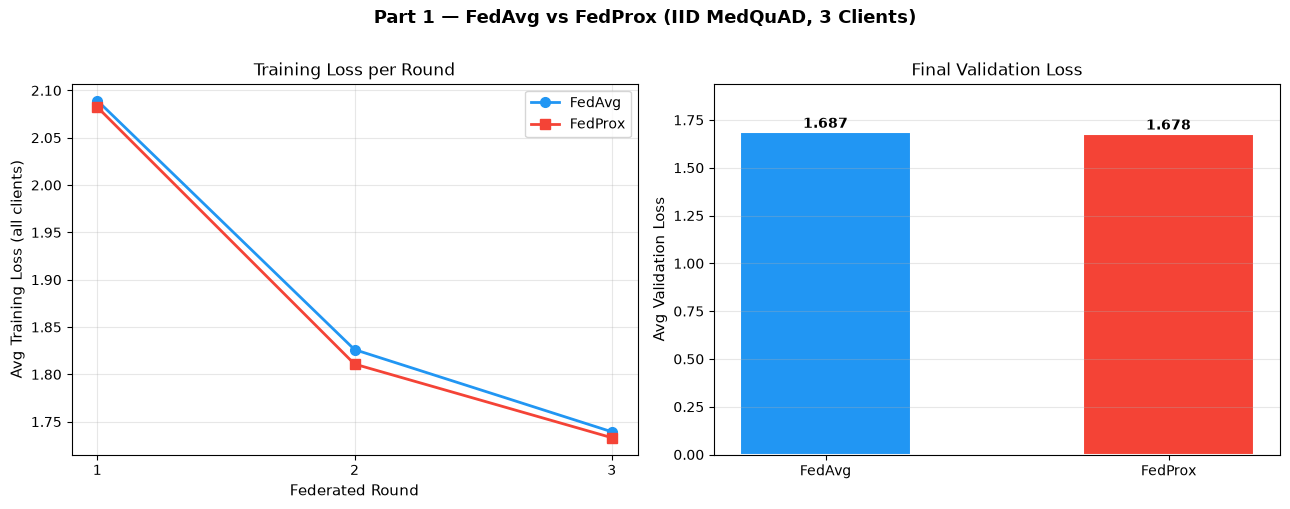

Plot saved.


In [16]:
COLORS = {"FedAvg": "#2196F3", "FedProx": "#F44336"}
MARKERS = {"FedAvg": "o", "FedProx": "s"}

rounds = list(range(1, CFG.total_rounds + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part 1 — FedAvg vs FedProx (IID MedQuAD, 3 Clients)",
             fontsize=13, fontweight="bold", y=1.01)

# Training loss per round
ax = axes[0]
for algo in ALGORITHMS:
    avg_losses = [np.mean(r) for r in results[algo]]
    ax.plot(rounds, avg_losses, color=COLORS[algo], marker=MARKERS[algo],
            linewidth=2, markersize=7, label=algo)
ax.set_xlabel("Federated Round", fontsize=11)
ax.set_ylabel("Avg Training Loss (all clients)", fontsize=11)
ax.set_title("Training Loss per Round", fontsize=12)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Final validation loss bar chart
ax = axes[1]
avg_val_losses = [np.mean(val_results[a]) for a in ALGORITHMS]
bars = ax.bar(ALGORITHMS, avg_val_losses,
              color=[COLORS[a] for a in ALGORITHMS],
              edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, avg_val_losses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Avg Validation Loss", fontsize=11)
ax.set_title("Final Validation Loss", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, max(avg_val_losses) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, "part1_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")


## 12. Algorithm Notes

### FedAvg
- **Best for:** IID data, quick baselines, when simplicity matters
- **Weakness:** Client drift under non-IID data
- **Cost:** Lowest — no extra communication or computation

### FedProx
- **Best for:** Heterogeneous systems, non-IID data
- **Key idea:** Proximal term keeps local models close to global; high `μ` = safer but slower; low `μ` → behaves like FedAvg
- **Tune:** `CFG.fedprox_mu` (try 0.001 → 1.0; start with 0.01)
- **Cost:** Tiny extra compute per batch

---
**Next step:** Run `federated_part2_scaffold_fedadam.ipynb`, then open `federated_part3_comparison.ipynb` to see the full 4-algorithm comparison.
